In [72]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import butter, sosfilt
import os
import glob

print("All libraries loaded successfully!")
print(f"librosa version : {librosa.__version__}")
print(f"numpy version   : {np.__version__}")

All libraries loaded successfully!
librosa version : 0.11.0
numpy version   : 2.1.3


In [73]:
RAW_DIR    = "../data/raw/"
OUTPUT_DIR = "../output/preprocessed/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

wav_files = glob.glob(os.path.join(RAW_DIR, "*.wav"))
print(f"Found {len(wav_files)} .wav files")
print("First 3 files:")
for f in wav_files[:3]:
    print("  ", f)

Found 920 .wav files
First 3 files:
   ../data/raw\101_1b1_Al_sc_Meditron.wav
   ../data/raw\101_1b1_Pr_sc_Meditron.wav
   ../data/raw\102_1b1_Ar_sc_Meditron.wav


In [74]:
# Loading a single file to test for checking
test_file = wav_files[0]            
y, sr = librosa.load(test_file, sr=None)   

print(f"File         : {os.path.basename(test_file)}")
print(f"Sample rate  : {sr} Hz")
print(f"Duration     : {len(y)/sr:.2f} seconds")
print(f"Total samples: {len(y)}")
print(f"Min amplitude: {y.min():.4f}")
print(f"Max amplitude: {y.max():.4f}")

File         : 101_1b1_Al_sc_Meditron.wav
Sample rate  : 44100 Hz
Duration     : 20.00 seconds
Total samples: 882000
Min amplitude: -0.2002
Max amplitude: 0.4148


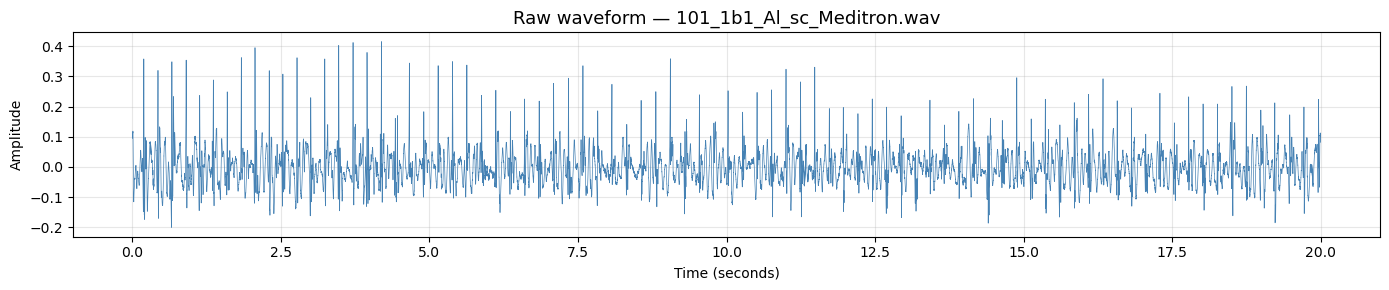

In [75]:
# Visualise the raw signal
def plot_waveform(signal, sr, title="Waveform", color="steelblue"):
    time = np.linspace(0, len(signal) / sr, num=len(signal))
    plt.figure(figsize=(14, 3))
    plt.plot(time, signal, color=color, linewidth=0.5)
    plt.title(title, fontsize=13)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_waveform(y, sr, title=f"Raw waveform — {os.path.basename(test_file)}")

In [76]:
# Band-pass filter 
def bandpass_filter(signal, sr, lowcut=100, highcut=2000, order=4):
    """
    Butterworth band-pass filter.
    Keeps only frequencies between lowcut and highcut Hz.
    
    lowcut  = 100 Hz  → removes body movement / ambient rumble
    highcut = 2000 Hz → removes stethoscope noise / high-freq interference
    order   = 4       → steepness of the roll-off (higher = sharper cutoff)
    """
    nyquist = sr / 2
    low  = lowcut  / nyquist     # normalise to 0–1
    high = highcut / nyquist     # normalise to 0–1
    
    sos = butter(order, [low, high], btype='bandpass', output='sos')
    
    filtered = sosfilt(sos, signal)
    return filtered


y_filtered = bandpass_filter(y, sr, lowcut=100, highcut=2000, order=4)

print("Filter applied.")
print(f"Filtered amplitude range: {y_filtered.min():.4f} to {y_filtered.max():.4f}")

Filter applied.
Filtered amplitude range: -0.1355 to 0.1012


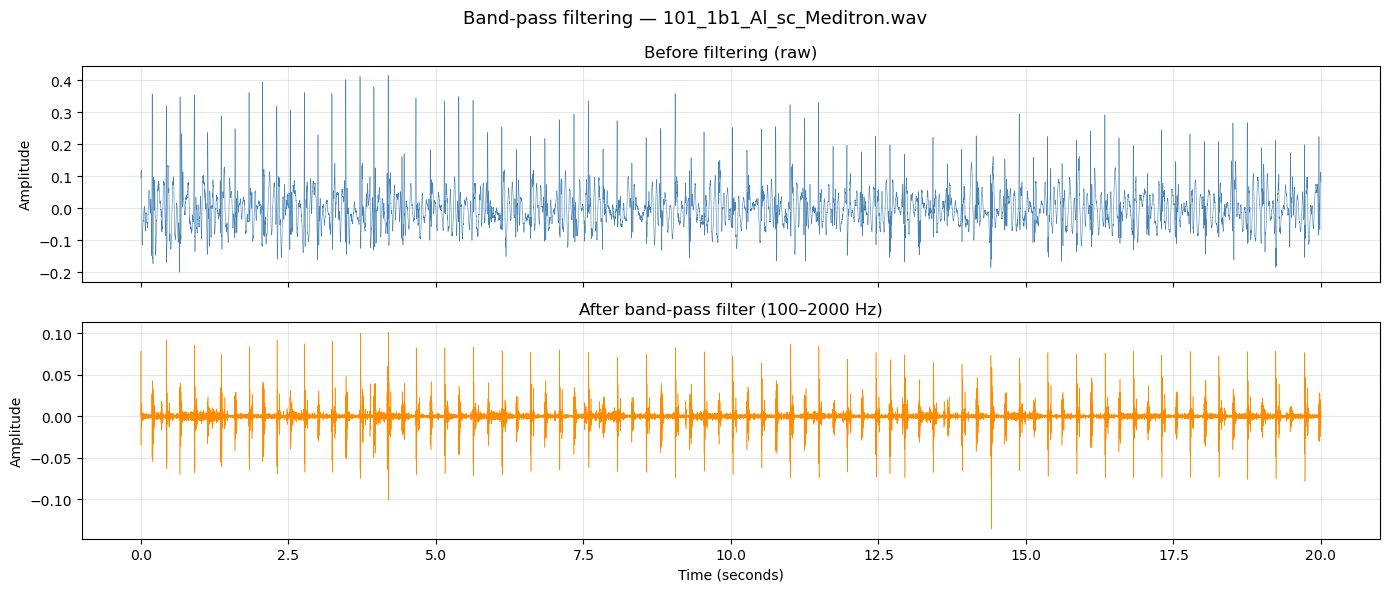

In [77]:
#Side-by-side comparison plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
time = np.linspace(0, len(y) / sr, num=len(y))

axes[0].plot(time, y, color='steelblue', linewidth=0.4)
axes[0].set_title("Before filtering (raw)", fontsize=12)
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, y_filtered, color='darkorange', linewidth=0.4)
axes[1].set_title("After band-pass filter (100–2000 Hz)", fontsize=12)
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Time (seconds)")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Band-pass filtering — {os.path.basename(test_file)}", fontsize=13)
plt.tight_layout()
plt.show()

In [78]:
#Standardisation
def standardise(signal):
    """
    Z-score normalisation: rescales signal so mean=0 and std=1.
    Applied per recording — each file is treated independently.
    """
    mean = np.mean(signal)
    std  = np.std(signal)
    
    if std < 1e-10:
        print("  Warning: near-silent signal detected, skipping standardisation.")
        return signal
    
    return (signal - mean) / std


y_standardised = standardise(y_filtered)

print(f"Mean after standardisation : {np.mean(y_standardised):.8f}  (target: ~0.0)")
print(f"Std  after standardisation : {np.std(y_standardised):.8f}   (target: ~1.0)")

Mean after standardisation : 0.00000000  (target: ~0.0)
Std  after standardisation : 1.00000000   (target: ~1.0)


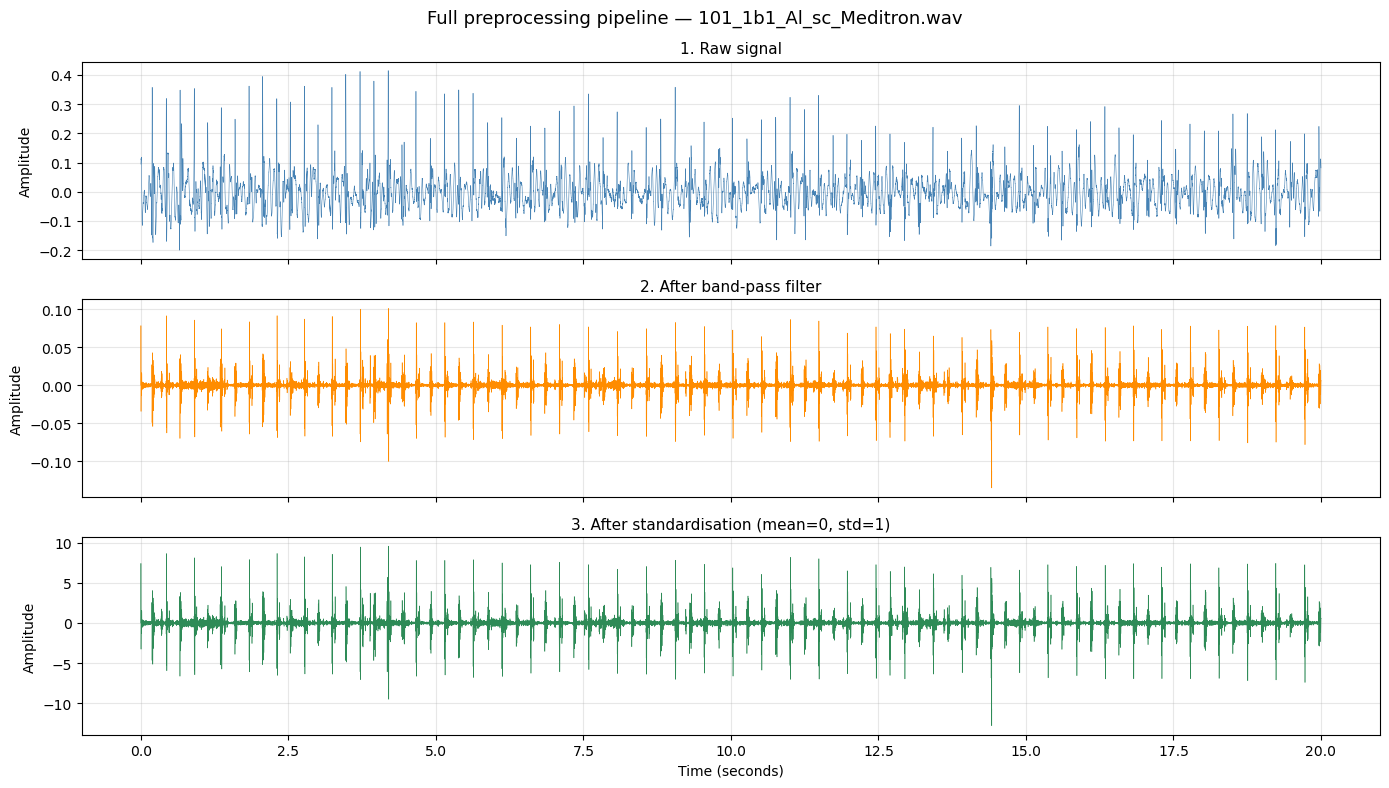

In [79]:
# visualisation of result
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
time = np.linspace(0, len(y) / sr, num=len(y))

axes[0].plot(time, y, color='steelblue', linewidth=0.4)
axes[0].set_title("1. Raw signal", fontsize=11)
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, y_filtered, color='darkorange', linewidth=0.4)
axes[1].set_title("2. After band-pass filter", fontsize=11)
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

axes[2].plot(time, y_standardised, color='seagreen', linewidth=0.4)
axes[2].set_title("3. After standardisation (mean=0, std=1)", fontsize=11)
axes[2].set_ylabel("Amplitude")
axes[2].set_xlabel("Time (seconds)")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Full preprocessing pipeline — {os.path.basename(test_file)}", fontsize=13)
plt.tight_layout()
plt.show()

In [80]:
#Saving preprocessed test file
output_filename = os.path.basename(test_file)
output_path = os.path.join(OUTPUT_DIR, output_filename)

sf.write(output_path, y_standardised, sr)
print(f"Saved to: {output_path}")

y_check, sr_check = librosa.load(output_path, sr=None)
print(f"Reload check — shape: {y_check.shape}, sample rate: {sr_check}")

Saved to: ../output/preprocessed/101_1b1_Al_sc_Meditron.wav
Reload check — shape: (882000,), sample rate: 44100


In [81]:
#Batch preprocessing all files by batching 

def preprocess_one_file(input_path, output_dir, lowcut=100, highcut=2000, order=4):
    """Load → filter → standardise → save. Returns True on success."""
    try:
        y, sr = librosa.load(input_path, sr=None)
        y_filt = bandpass_filter(y, sr, lowcut, highcut, order)
        y_std  = standardise(y_filt)
        
        out_path = os.path.join(output_dir, os.path.basename(input_path))
        sf.write(out_path, y_std, sr)
        return True
    except Exception as e:
        print(f"  ERROR on {os.path.basename(input_path)}: {e}")
        return False


success_count = 0
fail_count    = 0

for i, filepath in enumerate(wav_files):
    ok = preprocess_one_file(filepath, OUTPUT_DIR)
    if ok:
        success_count += 1
    else:
        fail_count += 1
    
    if (i + 1) % 50 == 0 or (i + 1) == len(wav_files):
        print(f"[{i+1}/{len(wav_files)}] Done — success: {success_count}, failed: {fail_count}")

print("\nBatch complete.")
print(f"  Successfully preprocessed : {success_count} files")
print(f"  Failed                    : {fail_count} files")

  ERROR on 104_1b1_Al_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 104_1b1_Ar_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 104_1b1_Ll_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 104_1b1_Lr_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 104_1b1_Pl_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 104_1b1_Pr_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 109_1b1_Al_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 109_1b1_Ar_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 109_1b1_Ll_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 109_1b1_Lr_sc_Litt3200.wav: Digital filter critical frequencies must be 0 < Wn < 1
  ERROR on 109_1b1_Pl_sc_Litt3200.wav: Digital filter critic

In [82]:
#Verifying output folder
output_files = glob.glob(os.path.join(OUTPUT_DIR, "*.wav"))
print(f"Files in output folder: {len(output_files)}")
print(f"Files in raw folder   : {len(wav_files)}")

if len(output_files) == len(wav_files):
    print("\nAll files preprocessed successfully.")
else:
    print(f"\nMismatch — {len(wav_files) - len(output_files)} files missing from output.")

Files in output folder: 920
Files in raw folder   : 920

All files preprocessed successfully.


In [83]:
#lisst of missing fil;es

output_files = glob.glob(os.path.join(OUTPUT_DIR, "*.wav"))

raw_names    = set(os.path.basename(f) for f in wav_files)
output_names = set(os.path.basename(f) for f in output_files)

missing_names = raw_names - output_names
print(f"Missing files: {len(missing_names)}")
print("\nList of missing files:")
for name in sorted(missing_names):
    print(" ", name)

Missing files: 0

List of missing files:


In [84]:
#this cell is for Retry missing files and print exact errors so that i can know the correct band to filter again

missing_paths = [f for f in wav_files if os.path.basename(f) in missing_names]

for filepath in missing_paths:
    fname = os.path.basename(filepath)
    try:
        y, sr = librosa.load(filepath, sr=None)
        print(f"OK  load  — {fname}  | sr={sr}, samples={len(y)}, duration={len(y)/sr:.2f}s")
        
        y_filt = bandpass_filter(y, sr, lowcut=100, highcut=2000, order=4)
        print(f"OK  filter — {fname}")
        
        y_std = standardise(y_filt)
        print(f"OK  stdise — {fname}  | mean={np.mean(y_std):.4f}, std={np.std(y_std):.4f}")
        
        out_path = os.path.join(OUTPUT_DIR, fname)
        sf.write(out_path, y_std, sr)
        print(f"OK  saved  — {fname}\n")
        
    except Exception as e:
        print(f"FAIL — {fname}")
        print(f"      Error: {type(e).__name__}: {e}\n")

In [85]:
#checking that to confirm exactly which files will be processed so that i wont get confuced!!
print(f"Files that WILL be processed now  : {len(missing_paths)}")
print(f"Files already in output (untouched): {len(output_files)}")
print(f"Total after retry should be        : {len(missing_paths) + len(output_files)}")
print()
print("Sample of files that will be retried:")
for f in sorted(missing_paths)[:5]:
    print(" ", os.path.basename(f))

Files that WILL be processed now  : 0
Files already in output (untouched): 920
Total after retry should be        : 920

Sample of files that will be retried:


In [86]:
#Fixed bandpass_filter andd handles low sample rate files (sr=4000 Hz)

def bandpass_filter(signal, sr, lowcut=100, highcut=2000, order=4):
    """
    Butterworth band-pass filter with automatic Nyquist safety cap.
    
    For files with sr=4000 Hz, Nyquist = 2000 Hz.
    Scipy requires Wn strictly < 1.0, so we cap highcut to 95% of Nyquist.
    For normal files (sr >= 8000 Hz) this cap has no effect.
    """
    nyquist = sr / 2

    safe_highcut = min(highcut, nyquist * 0.95)

    safe_lowcut = max(lowcut, nyquist * 0.01)

    if safe_lowcut >= safe_highcut:
        raise ValueError(
            f"Cannot design filter: lowcut={safe_lowcut:.1f} >= highcut={safe_highcut:.1f} "
            f"for sr={sr} Hz. Signal may have too low a sample rate."
        )

    low  = safe_lowcut  / nyquist
    high = safe_highcut / nyquist

    sos = butter(order, [low, high], btype='bandpass', output='sos')
    filtered = sosfilt(sos, signal)
    return filtered


print("Testing fix on a 4000 Hz file:")
print(f"  sr=4000  → Nyquist=2000, safe_highcut = {min(2000, 2000*0.95):.0f} Hz")
print(f"  sr=44100 → Nyquist=22050, safe_highcut = {min(2000, 22050*0.95):.0f} Hz  (unchanged)")
print("Filter function updated successfully.")

Testing fix on a 4000 Hz file:
  sr=4000  → Nyquist=2000, safe_highcut = 1900 Hz
  sr=44100 → Nyquist=22050, safe_highcut = 2000 Hz  (unchanged)
Filter function updated successfully.


In [87]:
retry_success = 0
retry_fail    = 0

for filepath in missing_paths:
    fname = os.path.basename(filepath)
    try:
        y, sr = librosa.load(filepath, sr=None)
        y_filt = bandpass_filter(y, sr, lowcut=100, highcut=2000, order=4)
        y_std  = standardise(y_filt)
        out_path = os.path.join(OUTPUT_DIR, fname)
        sf.write(out_path, y_std, sr)
        retry_success += 1
    except Exception as e:
        print(f"STILL FAILING — {fname}: {e}")
        retry_fail += 1

print(f"\nRetry complete.")
print(f"  Recovered : {retry_success} files")
print(f"  Still failing : {retry_fail} files")


Retry complete.
  Recovered : 0 files
  Still failing : 0 files


In [88]:
final_output = glob.glob(os.path.join(OUTPUT_DIR, "*.wav"))
print(f"Raw folder    : {len(wav_files)} files")
print(f"Output folder : {len(final_output)} files")

if len(final_output) == len(wav_files):
    print("\nAll 920 files successfully preprocessed!")
else:
    still_missing = set(os.path.basename(f) for f in wav_files) - \
                    set(os.path.basename(f) for f in final_output)
    print(f"\nStill missing {len(still_missing)} files:")
    for f in sorted(still_missing):
        print(" ", f)

Raw folder    : 920 files
Output folder : 920 files

All 920 files successfully preprocessed!
